# Missing Data Checks

Here we will go through all the possible ways to check what data is missing, in which datasets and in which way they are missing.

## 1. Setup

We first import the required packages, locate the project folder, and connect to the DuckDB database created in the setup notebook.

In [1]:
from pathlib import Path
import sys
import duckdb
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

print(f"Connected to DuckDB database: {DUCKDB_PATH}")

Connected to DuckDB database: C:\Users\hp\OneDrive - WU Wien\Desktop\Denis_Masters\Semester 2\Solution Engineering - Python\Spotify_Project\spotify_project\data\interim\spotify.duckdb


## 2. Available Tables

This step checks which tables are currently stored inside the DuckDB database.

In [2]:
tables = con.execute("SHOW TABLES").df()
tables

,name
0,albums
1,artists
2,audio_features
3,lyrics_features
4,tracks


## 3. Table Inventory

Before checking the content in detail, we create a compact overview of all tables in the database.

This gives us a first idea of the dataset structure and helps us see which tables are large, which are small, and where we may need to be careful later.

In [3]:
table_names = tables["name"].tolist()

table_inventory = []

for table in table_names:
    n_rows = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    schema = con.execute(f"DESCRIBE {table}").df()
    n_cols = schema.shape[0]
    
    table_inventory.append({
        "table": table,
        "rows": n_rows,
        "columns": n_cols
    })

table_inventory_df = pd.DataFrame(table_inventory).sort_values("rows", ascending=False)

table_inventory_df

,table,rows,columns
4,tracks,101939,32
2,audio_features,101909,209
3,lyrics_features,94954,8
0,albums,75511,16
1,artists,56129,9


The database contains several connected tables with different sizes.  
This is important because not every table will contribute equally to the analysis. Larger tables may contain the main track-level data, while smaller tables may contain metadata or additional features.

## 4. Table Size Comparison

Here we visualize the number of rows per table.  
This makes it easier to quickly see which datasets dominate the project and which ones are much smaller.

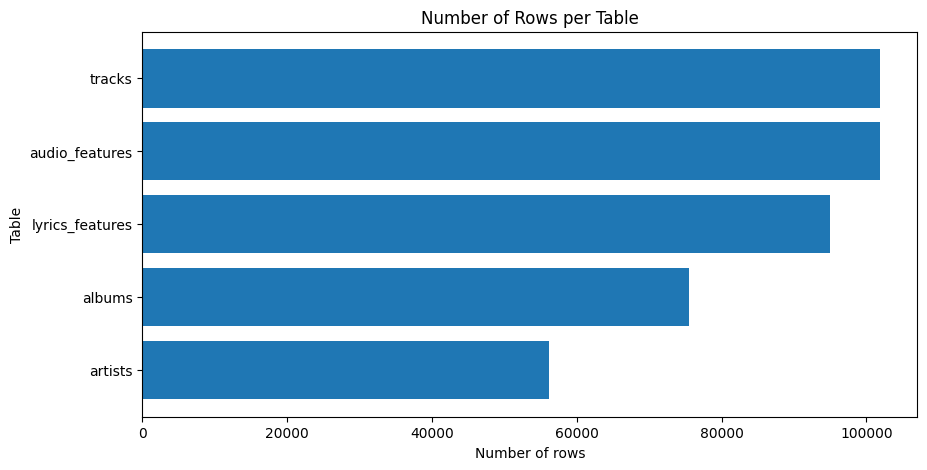

In [4]:
import matplotlib.pyplot as plt

plot_df = table_inventory_df.sort_values("rows", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["table"], plot_df["rows"])
plt.xlabel("Number of rows")
plt.ylabel("Table")
plt.title("Number of Rows per Table")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

The table sizes are not equal, which means we need to be careful when joining datasets later.  
If one table has fewer records than another, some tracks may lose information during merging.

## 5. Column Quality Overview

Before analyzing the data itself, we inspect the structure of each table.

This helps identify potentially problematic columns, unexpected data types, and columns that may require cleaning before further analysis.

In [5]:
for table in table_names:
    print("\n" + "=" * 80)
    print(f"TABLE: {table}")
    print("=" * 80)

    schema = con.execute(f"DESCRIBE {table}").df()

    display(schema)


TABLE: albums


,column_name,column_type,null,key,default,extra
0,column00,BIGINT,YES,None,None,None
1,album_type,VARCHAR,YES,None,None,None
2,artist_id,VARCHAR,YES,None,None,None
3,available_markets,VARCHAR,YES,None,None,None
4,external_urls,VARCHAR,YES,None,None,None
5,href,VARCHAR,YES,None,None,None
6,id,VARCHAR,YES,None,None,None
7,images,VARCHAR,YES,None,None,None
8,name,VARCHAR,YES,None,None,None
9,release_date,VARCHAR,YES,None,None,None



TABLE: artists


,column_name,column_type,null,key,default,extra
0,column0,BIGINT,YES,None,None,None
1,artist_popularity,BIGINT,YES,None,None,None
2,followers,BIGINT,YES,None,None,None
3,genres,VARCHAR,YES,None,None,None
4,id,VARCHAR,YES,None,None,None
5,name,VARCHAR,YES,None,None,None
6,track_id,VARCHAR,YES,None,None,None
7,track_name_prev,VARCHAR,YES,None,None,None
8,type,VARCHAR,YES,None,None,None



TABLE: audio_features


,column_name,column_type,null,key,default,extra
0,column000,BIGINT,YES,None,None,None
1,Chroma_1,DOUBLE,YES,None,None,None
2,Chroma_10,DOUBLE,YES,None,None,None
3,Chroma_11,DOUBLE,YES,None,None,None
4,Chroma_12,DOUBLE,YES,None,None,None
...,...,...,...,...,...,...
204,spectral_bandwith,DOUBLE,YES,None,None,None
205,spectral_centroid,DOUBLE,YES,None,None,None
206,spectral_rollOff_max,DOUBLE,YES,None,None,None
207,spectral_rollOff_min,DOUBLE,YES,None,None,None



TABLE: lyrics_features


,column_name,column_type,null,key,default,extra
0,column0,BIGINT,YES,None,None,None
1,mean_syllables_word,DOUBLE,YES,None,None,None
2,mean_words_sentence,DOUBLE,YES,None,None,None
3,n_sentences,BIGINT,YES,None,None,None
4,n_words,BIGINT,YES,None,None,None
5,sentence_similarity,DOUBLE,YES,None,None,None
6,track_id,VARCHAR,YES,None,None,None
7,vocabulary_wealth,DOUBLE,YES,None,None,None



TABLE: tracks


,column_name,column_type,null,key,default,extra
0,column00,BIGINT,YES,None,None,None
1,acousticness,DOUBLE,YES,None,None,None
2,album_id,VARCHAR,YES,None,None,None
3,analysis_url,VARCHAR,YES,None,None,None
4,artists_id,VARCHAR,YES,None,None,None
5,available_markets,VARCHAR,YES,None,None,None
6,country,VARCHAR,YES,None,None,None
7,danceability,DOUBLE,YES,None,None,None
8,disc_number,DOUBLE,YES,None,None,None
9,duration_ms,DOUBLE,YES,None,None,None


Observation:
Several tables contain automatically generated index columns originating from earlier exports. These columns do not contain business-relevant information and will likely be removed during preprocessing.

# Missing Data Checks

Now here we will do whole thorough missing data checks for every dataset.

## Identifier Uniqueness Check

Many tables contain unique identifiers such as track IDs, artist IDs, album IDs, or playlist IDs.

Before performing joins or building recommendation models, we verify whether these identifiers are actually unique.

In [6]:
id_checks = [
    ("tracks", "id"),
    ("artists", "id"),
    ("albums", "id"),
    ("audio_features", "track_id"),
    ("lyrics_features", "track_id")
]

results = []

for table, col in id_checks:

    total_rows = con.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]

    unique_ids = con.execute(
        f"SELECT COUNT(DISTINCT {col}) FROM {table}"
    ).fetchone()[0]

    results.append({
        "table": table,
        "id_column": col,
        "rows": total_rows,
        "unique_ids": unique_ids,
        "duplicate_ids": total_rows - unique_ids
    })

pd.DataFrame(results)

,table,id_column,rows,unique_ids,duplicate_ids
0,tracks,id,101939,101939,0
1,artists,id,56129,56129,0
2,albums,id,75511,75511,0
3,audio_features,track_id,101909,101909,0
4,lyrics_features,track_id,94954,94954,0


Duplicate IDs and duplicate songs are not the same thing. While all identifier columns are unique, tracks may still appear multiple times under different Spotify IDs due to remasters, live versions, deluxe editions, or playlist-specific duplicates.

In [7]:
coverage = pd.DataFrame({
    "table": [
        "tracks",
        "audio_features",
        "lyrics_features"
    ],
    "rows": [
        len(con.execute("SELECT * FROM tracks").df()),
        len(con.execute("SELECT * FROM audio_features").df()),
        len(con.execute("SELECT * FROM lyrics_features").df())
    ]
})

coverage["coverage_vs_tracks"] = (
    coverage["rows"] / coverage.loc[0, "rows"] * 100
).round(2)

coverage

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,table,rows,coverage_vs_tracks
0,tracks,101939,100.00
1,audio_features,101909,99.97
2,lyrics_features,94954,93.15


In [8]:
tracks_df = con.execute("""
SELECT id
FROM tracks
""").df()

audio_df = con.execute("""
SELECT track_id
FROM audio_features
""").df()

lyrics_df = con.execute("""
SELECT track_id
FROM lyrics_features
""").df()

missing_audio = ~tracks_df["id"].isin(audio_df["track_id"])
missing_lyrics = ~tracks_df["id"].isin(lyrics_df["track_id"])

print(f"Tracks missing audio features: {missing_audio.sum():,}")
print(f"Tracks missing lyrics features: {missing_lyrics.sum():,}")

Tracks missing audio features: 30
Tracks missing lyrics features: 6,985


### Coverage Summary

The audio feature dataset covers almost the entire track collection, with only 30 tracks missing audio information. This suggests that audio-based analyses can be performed on nearly all tracks.

Lyrics features show lower coverage, with around 7% of tracks missing lyric-related information. This is expected, as some songs may not have available lyrics, may be instrumental, or may have failed during lyric extraction and preprocessing.

## Dataset Match Quality

Since the project combines multiple datasets, it is important to verify that records can be matched correctly across tables.

The following check identifies tracks that exist in the main track dataset but are missing corresponding audio or lyric information.

In [9]:
coverage_summary = pd.DataFrame({
    "Feature Set": ["Audio Features", "Lyrics Features"],
    "Missing Tracks": [
        missing_audio.sum(),
        missing_lyrics.sum()
    ],
    "Coverage (%)": [
        round((1 - missing_audio.mean()) * 100, 2),
        round((1 - missing_lyrics.mean()) * 100, 2)
    ]
})

coverage_summary

,Feature Set,Missing Tracks,Coverage (%)
0,Audio Features,30,99.97
1,Lyrics Features,6985,93.15


## 7. Missing Value Audit

Missing information can affect both exploratory analysis and recommendation performance.

We therefore inspect missing values across all tables before continuing with deeper analysis.

In [10]:
missing_like_summary = []

missing_text_values = ["", " ", "None", "none", "NULL", "null", "NaN", "nan", "[]", "{}"]

for table in table_names:
    df = con.execute(f"SELECT * FROM {table}").df()
    
    for col in df.columns:
        total = len(df)
        
        real_missing = df[col].isna().sum()
        
        if df[col].dtype == "object":
            placeholder_missing = df[col].astype(str).str.strip().isin(missing_text_values).sum()
            minus_one_values = (df[col].astype(str).str.strip() == "-1").sum()
        else:
            placeholder_missing = 0
            minus_one_values = (df[col] == -1).sum()
        
        missing_like_total = real_missing + placeholder_missing + minus_one_values
        
        missing_like_summary.append({
            "table": table,
            "column": col,
            "real_missing": real_missing,
            "placeholder_missing": placeholder_missing,
            "minus_one_values": minus_one_values,
            "missing_like_total": missing_like_total,
            "missing_like_pct": round(missing_like_total / total * 100, 2)
        })

missing_like_df = (
    pd.DataFrame(missing_like_summary)
    .sort_values("missing_like_pct", ascending=False)
)

missing_like_df.head(50)

,table,column,real_missing,placeholder_missing,minus_one_values,missing_like_total,missing_like_pct
19,artists,genres,0,23540,0,23540,41.94
237,lyrics_features,n_sentences,0,0,15534,15534,16.36
238,lyrics_features,n_words,0,0,15534,15534,16.36
239,lyrics_features,sentence_similarity,0,0,15534,15534,16.36
235,lyrics_features,mean_syllables_word,0,0,15534,15534,16.36
241,lyrics_features,vocabulary_wealth,0,0,15534,15534,16.36
236,lyrics_features,mean_words_sentence,0,0,15534,15534,16.36
259,tracks,lyrics,0,799,0,799,0.78
7,albums,images,0,16,0,16,0.02
178,audio_features,MFCC_20,0,0,0,0,0.00


## Lyrics Placeholder Check

The lyrics data needs extra attention because missing or failed lyric extraction may be encoded with placeholder values, especially `-1`.

Before using lyrics or lyric features, we check how often these placeholders appear.

In [14]:
lyrics_placeholder_check = []

# Check lyrics column inside tracks
tracks_df = con.execute("SELECT id, name, lyrics FROM tracks").df()

lyrics_placeholder_check.append({
    "source": "tracks.lyrics",
    "total_rows": len(tracks_df),
    "real_missing": tracks_df["lyrics"].isna().sum(),
    "minus_one_values": (tracks_df["lyrics"].astype(str).str.strip() == "-1").sum(),
    "empty_strings": (tracks_df["lyrics"].astype(str).str.strip() == "").sum()
})

# Check all columns in lyrics_features
lyrics_features_df = con.execute("SELECT * FROM lyrics_features").df()

for col in lyrics_features_df.columns:
    lyrics_placeholder_check.append({
        "source": f"lyrics_features.{col}",
        "total_rows": len(lyrics_features_df),
        "real_missing": lyrics_features_df[col].isna().sum(),
        "minus_one_values": (
            lyrics_features_df[col].astype(str).str.strip() == "-1"
        ).sum(),
        "empty_strings": (
            lyrics_features_df[col].astype(str).str.strip() == ""
        ).sum()
    })

lyrics_placeholder_df = pd.DataFrame(lyrics_placeholder_check)
lyrics_placeholder_df["minus_one_pct"] = (
    lyrics_placeholder_df["minus_one_values"] / lyrics_placeholder_df["total_rows"] * 100
).round(2)

lyrics_placeholder_df.sort_values("minus_one_pct", ascending=False)

,source,total_rows,real_missing,minus_one_values,empty_strings,minus_one_pct
4,lyrics_features.n_sentences,94954,0,15534,0,16.36
5,lyrics_features.n_words,94954,0,15534,0,16.36
0,tracks.lyrics,101939,0,0,799,0.00
1,lyrics_features.column0,94954,0,0,0,0.00
2,lyrics_features.mean_syllables_word,94954,0,0,0,0.00
3,lyrics_features.mean_words_sentence,94954,0,0,0,0.00
6,lyrics_features.sentence_similarity,94954,0,0,0,0.00
7,lyrics_features.track_id,94954,0,0,0,0.00
8,lyrics_features.vocabulary_wealth,94954,0,0,0,0.00


In [15]:
lyrics_df = con.execute("""
SELECT *
FROM lyrics_features
""").df()

failed_rows = lyrics_df[
    lyrics_df["n_words"] == -1
]

print(f"Failed lyric feature rows: {len(failed_rows):,}")

failed_rows.head()

Failed lyric feature rows: 15,534


,column0,mean_syllables_word,mean_words_sentence,n_sentences,n_words,sentence_similarity,track_id,vocabulary_wealth
0,0,-1.0,-1.0,-1,-1,-1.0,5KIfHjHI5NIsPHNt58qua0,-1.0
36,36,-1.0,-1.0,-1,-1,-1.0,36fswRCmYh3PZut815LyhH,-1.0
38,38,-1.0,-1.0,-1,-1,-1.0,2kgxYag8woDOgxFIrkGyYc,-1.0
41,41,-1.0,-1.0,-1,-1,-1.0,4aZsMBnqCHrU3V4kC6sxoh,-1.0
43,43,-1.0,-1.0,-1,-1,-1.0,2sbUWtAhUyGYXiCch6OcmO,-1.0


In [16]:
failed_rows.describe(include="all")

,column0,mean_syllables_word,mean_words_sentence,n_sentences,n_words,sentence_similarity,track_id,vocabulary_wealth
count,15534.000000,15534.0,15534.0,15534.0,15534.0,15534.0,15534,15534.0
unique,NaN,NaN,NaN,NaN,NaN,NaN,15534,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,5KIfHjHI5NIsPHNt58qua0,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
mean,47264.848268,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,-1.0
std,27580.729294,0.0,0.0,0.0,0.0,0.0,NaN,0.0
min,0.000000,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,-1.0
25%,23412.250000,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,-1.0
50%,46998.500000,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,-1.0
75%,71670.500000,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,-1.0


In [17]:
lyrics_df = con.execute("""
SELECT *
FROM lyrics_features
""").df()

lyric_feature_cols = [
    "mean_syllables_word",
    "mean_words_sentence",
    "n_sentences",
    "n_words",
    "sentence_similarity",
    "vocabulary_wealth"
]

for col in lyric_feature_cols:
    print(
        f"{col}: {(lyrics_df[col] == -1).sum():,}"
    )

mean_syllables_word: 15,534
mean_words_sentence: 15,534
n_sentences: 15,534
n_words: 15,534
sentence_similarity: 15,534
vocabulary_wealth: 15,534


The lyrics feature table contains 15,534 rows where all lyric feature values are set to `-1`.

This strongly suggests that `-1` is not a real feature value, but a placeholder for failed or unavailable lyric feature extraction. These rows should therefore not be treated as valid lyric data in later analysis.

## Cleaning Decision: Lyrics Feature Placeholders

For future analysis, lyric feature rows with `-1` values should be handled as missing or invalid.

Since all lyric feature columns are affected at the same time, these rows likely represent tracks where lyric feature extraction failed completely.

In [18]:
valid_lyrics_features = lyrics_df[lyrics_df["n_words"] != -1].copy()

print(f"Original lyrics feature rows: {len(lyrics_df):,}")
print(f"Valid lyrics feature rows: {len(valid_lyrics_features):,}")
print(f"Invalid lyrics feature rows: {len(lyrics_df) - len(valid_lyrics_features):,}")
print(f"Valid lyrics feature coverage vs all tracks: {len(valid_lyrics_features) / len(tracks_df) * 100:.2f}%")

Original lyrics feature rows: 94,954
Valid lyrics feature rows: 79,420
Invalid lyrics feature rows: 15,534
Valid lyrics feature coverage vs all tracks: 77.91%


### Lyrics Feature Quality

At first glance, lyric features appeared to cover 93.15% of all tracks. However, a deeper inspection revealed that 15,534 rows contain only placeholder values (`-1`) across all lyric feature columns.

These rows likely represent failed lyric feature extraction and therefore do not contain usable information. After excluding these records, the effective lyric feature coverage decreases to 77.91% of all tracks.

This issue should be considered in all later lyric-based analyses.

## Last Checks in the Missing Data Part

In [19]:
empty_string_results = []

for table in table_names:

    df = con.execute(f"SELECT * FROM {table}").df()

    object_cols = df.select_dtypes(include="object").columns

    for col in object_cols:

        empty_count = (
            df[col]
            .astype(str)
            .str.strip()
            .eq("")
            .sum()
        )

        if empty_count > 0:

            empty_string_results.append({
                "table": table,
                "column": col,
                "empty_strings": empty_count
            })

pd.DataFrame(empty_string_results).sort_values(
    "empty_strings",
    ascending=False
)

,table,column,empty_strings
0,tracks,lyrics,799


In [20]:
constant_columns = []

for table in table_names:

    df = con.execute(f"SELECT * FROM {table}").df()

    for col in df.columns:

        unique_values = df[col].nunique(dropna=False)

        if unique_values == 1:

            constant_columns.append({
                "table": table,
                "column": col
            })

pd.DataFrame(constant_columns)

,table,column
0,albums,type
1,artists,type
2,tracks,type


In [21]:
low_variance_columns = []

for table in table_names:

    df = con.execute(f"SELECT * FROM {table}").df()

    for col in df.columns:

        top_freq = (
            df[col]
            .value_counts(dropna=False, normalize=True)
            .head(1)
            .iloc[0]
        )

        if top_freq > 0.99:

            low_variance_columns.append({
                "table": table,
                "column": col,
                "dominant_share": round(top_freq * 100, 2)
            })

pd.DataFrame(low_variance_columns)

,table,column,dominant_share
0,albums,type,100.0
1,artists,type,100.0
2,tracks,type,100.0


In [22]:
numeric_issues = []

for table in table_names:

    df = con.execute(f"SELECT * FROM {table}").df()

    numeric_cols = df.select_dtypes(include=["number"]).columns

    for col in numeric_cols:

        negative_count = (df[col] < 0).sum()

        if negative_count > 0:

            numeric_issues.append({
                "table": table,
                "column": col,
                "negative_values": int(negative_count)
            })

pd.DataFrame(numeric_issues).sort_values(
    "negative_values",
    ascending=False
)

,table,column,negative_values
54,audio_features,entropy_energy,101909
61,tracks,loudness,101896
0,audio_features,MFCC_1,101663
22,audio_features,MFCC_3,90042
45,audio_features,MFCC_7,88490
7,audio_features,MFCC_16,87961
38,audio_features,MFCC_44,85588
12,audio_features,MFCC_20,84048
24,audio_features,MFCC_31,83787
36,audio_features,MFCC_42,83119


### Missing Data Summary

The dataset does not contain many real null values, but several hidden missing-data patterns were found.

The most important issues are:

- 23,540 artists have empty genre lists (`[]`), meaning genre information is missing for 41.94% of artists.
- 6,985 tracks do not have a matching lyrics feature row.
- 15,534 lyrics feature rows contain only `-1` values, which indicates failed lyric feature extraction.
- After removing invalid lyric feature rows, usable lyric feature coverage drops to 77.91%.
- 799 tracks contain empty lyrics.
- The `type` columns in albums, artists, and tracks are constant and do not add useful information.

In [23]:
# Check valid value ranges for selected Spotify track features

tracks_df = con.execute("SELECT * FROM tracks").df()

range_checks = {
    "danceability": (0, 1),
    "energy": (0, 1),
    "speechiness": (0, 1),
    "acousticness": (0, 1),
    "instrumentalness": (0, 1),
    "liveness": (0, 1),
    "valence": (0, 1),
    "popularity": (0, 100),
    "tempo": (0, None),
    "duration_ms": (0, None),
    "track_number": (1, None),
    "disc_number": (1, None),
    "time_signature": (1, 7),
    "mode": (0, 1),
    "key": (-1, 11)
}

range_issues = []

for col, (min_val, max_val) in range_checks.items():
    if col in tracks_df.columns:
        below_min = (tracks_df[col] < min_val).sum()
        above_max = (tracks_df[col] > max_val).sum() if max_val is not None else 0
        
        if below_min > 0 or above_max > 0:
            range_issues.append({
                "column": col,
                "below_min": below_min,
                "above_max": above_max
            })

pd.DataFrame(range_issues)

,column,below_min,above_max
0,time_signature,367,0


In [24]:
tracks_df.loc[
    tracks_df["time_signature"] < 1,
    ["id", "name", "time_signature"]
].head(20)

,id,name,time_signature
507,4BevCAsXMj3gyKz0FVC40I,Plans,0.0
1407,3E87phZUgHIoLgZMft8IRs,Gretchen Rubin - When I'm Feeling Blue,0.0
1522,00JBUb3hP0P0RdZkf5z0jA,The Irresistible Force,0.0
2436,1Ry1OlqBSTxRCY8uMNYWrE,Band Aids,0.0
2455,14q3y72rixamMVSNDL89gW,Quicken,0.0
2695,5ibBMgn0qcbkZv1jsdezn4,Folge 8: Lied 2,0.0
3452,5kE2qukdSe8LFkQrt3PA5y,Folge 10: Lied 1,0.0
3499,5L3ixDw9iR8vzqZdy3BUTp,Folge 9: Lied 3,0.0
3846,15RGTXA9B8veOavTjXvFXa,Legit Boss,0.0
4007,4Y0imedsJafk8aTAwG4VNX,LeLe Pons - Intro,0.0


In [25]:
tracks_df["time_signature"].value_counts().sort_index()

time_signature
0.0      367
1.0     1175
3.0    10030
4.0    88020
5.0     2347
Name: count, dtype: int64

In [26]:
lyrics_status = pd.DataFrame({
    "Category": [
        "All Tracks",
        "Tracks with Lyrics Features",
        "Tracks with Valid Lyrics Features"
    ],
    "Count": [
        101939,
        94954,
        79420
    ]
})

lyrics_status["Percentage"] = (
    lyrics_status["Count"] /
    lyrics_status.loc[0, "Count"] * 100
).round(2)

lyrics_status

,Category,Count,Percentage
0,All Tracks,101939,100.00
1,Tracks with Lyrics Features,94954,93.15
2,Tracks with Valid Lyrics Features,79420,77.91


# More into EDA than here

These chunks to keep later for EDA, so the Missing data search is done.

### Time Signature Values 

A small number of tracks (367) contain a time signature value of 0.

Since Spotify time signatures are normally positive integers, these values likely represent unavailable or unknown time signatures rather than actual musical meters. The proportion is very small (0.36% of all tracks) and therefore is not expected to have a major impact on the analysis.

In [27]:
tracks_df = con.execute("""
SELECT playlist, country
FROM tracks
""").df()

print("Unique playlists:", tracks_df["playlist"].nunique())
print("Unique countries:", tracks_df["country"].nunique())

tracks_df["country"].value_counts().head(20)

Unique playlists: 3800
Unique countries: 3


country
AR    50437
FI    30444
BE    21058
Name: count, dtype: int64

In [28]:
playlist_sizes = (
    tracks_df["playlist"]
    .value_counts()
    .reset_index()
)

playlist_sizes.columns = ["playlist", "track_count"]

playlist_sizes.describe()

,track_count
count,3800.000000
mean,26.826053
std,19.468294
min,1.000000
25%,12.000000
50%,23.500000
75%,38.000000
max,129.000000


### Playlist Structure

The dataset contains 3,800 playlists distributed across three countries (Argentina, Finland, and Belgium).

Playlist sizes are relatively balanced, with a median of 24 tracks and a maximum of 129 tracks. No extremely large playlists were found, suggesting that playlist-level bias caused by oversized collections is limited.

### Genre Availability

Genre information is available for a large portion of the artist dataset, but not for all artists.

Around 42% of artists have an empty genre list (`[]`), indicating that Spotify did not provide genre classifications for these artists. As a result, genre-based analyses will only represent a subset of the available artists and tracks.

In [ ]:
artists_df = con.execute("""
SELECT genres
FROM artists
""").df()

artists_df["genres"].value_counts(dropna=False).head(20)

genres
[]                                                                   23540
['focus']                                                              177
['chillhop', 'lo-fi beats']                                             96
['classical piano']                                                     85
['orchestra']                                                           75
['dutch hip hop']                                                       74
['k-pop']                                                               73
['german hip hop']                                                      72
['lo-fi beats']                                                         70
['danish hip hop', 'danish pop']                                        66
['pop edm']                                                             65
['deep swedish hip hop']                                                65
['christian hip hop', 'christian trap']                                 64
['brazilian electr

The genre column does not contain real null values, but many artists have an empty genre list `[]`.

This means genre information is structurally present, but unavailable for a large share of artists. Because of this, genre-based analysis is still possible, but it will not cover the full artist dataset.

In [ ]:
artists_df = con.execute("""
SELECT id, name, genres
FROM artists
""").df()

empty_genres = artists_df[
    artists_df["genres"].astype(str).str.strip() == "[]"
]

print(f"Artists with empty genres: {len(empty_genres):,}")
print(f"Unique artist IDs with empty genres: {empty_genres['id'].nunique():,}")
print(f"Unique artist names with empty genres: {empty_genres['name'].nunique():,}")

empty_genres.head()

Artists with empty genres: 23,540
Unique artist IDs with empty genres: 23,540
Unique artist names with empty genres: 23,325


,id,name,genres
1,1dLnVku4VQUOLswwDFvRc9,The Grenadines,[]
5,38VBjthd0szbS6wpDMafrb,Filhos,[]
6,36mHwYa65L0WZbAXY2iSGw,Eloq,[]
7,1jJyy00XfxjB4tMAv5OT0q,Fravær,[]
8,10A8WbBJ0zW8MnvTsUL6os,Camille Pépin,[]


In [ ]:
artists_df = con.execute("""
SELECT genres
FROM artists
""").df()

valid_genres = artists_df[
    artists_df["genres"].astype(str).str.strip() != "[]"
].copy()

valid_genres["genre_count"] = (
    valid_genres["genres"]
    .astype(str)
    .str.count(",")
    + 1
)

valid_genres["genre_count"].describe()

count    32589.000000
mean         2.675811
std          2.411894
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         30.000000
Name: genre_count, dtype: float64

In [29]:
con.close()